Project title: Demand Forecast for an online Reatil store

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
filepath = '/content/drive/MyDrive/marketBasketData/Online Retail.xlsx'

In [63]:
import pickle

In [3]:
df = pd.read_excel(filepath)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [6]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [7]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df_original = df.copy()

In [9]:
df_original

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [11]:
df_clean = df.dropna(subset=['Description', 'CustomerID'])

In [12]:
df_clean.shape

(406829, 8)

In [13]:
df_clean.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [14]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [15]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [16]:
df_clean['Date'] = df_clean['InvoiceDate'].dt.date

In [17]:
daily_df = df_clean.groupby('Date')['Quantity'].sum().reset_index()
daily_df.columns = ['Date', 'TotalQuantity']

In [18]:
daily_df.head()

,Date,TotalQuantity
0,2010-12-01,24215
1,2010-12-02,31142
2,2010-12-03,11839
3,2010-12-05,16449
4,2010-12-06,16291


In [19]:
daily_df.shape

(305, 2)

Exploratory data analysis

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
daily_df['Date'] = pd.to_datetime(daily_df['Date'])


Plot for daily demand trend

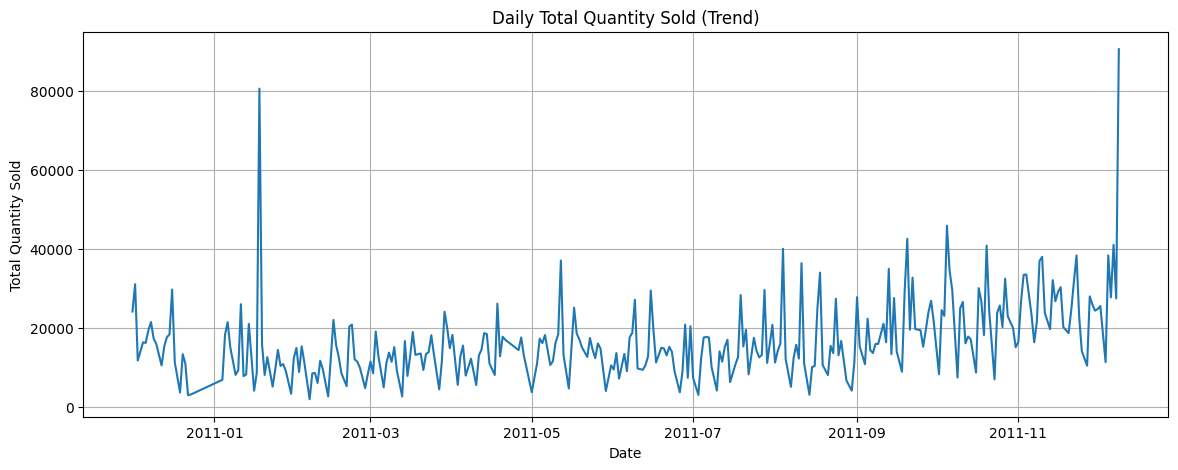

In [22]:
plt.figure(figsize=(14,5))
plt.plot(daily_df['Date'], daily_df['TotalQuantity'])
plt.title("Daily Total Quantity Sold (Trend)")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.grid(True)
plt.show()

The plot shows high day to day variability in total sales, the business also has a consistent baseline level of sales


Histogram for daily demand

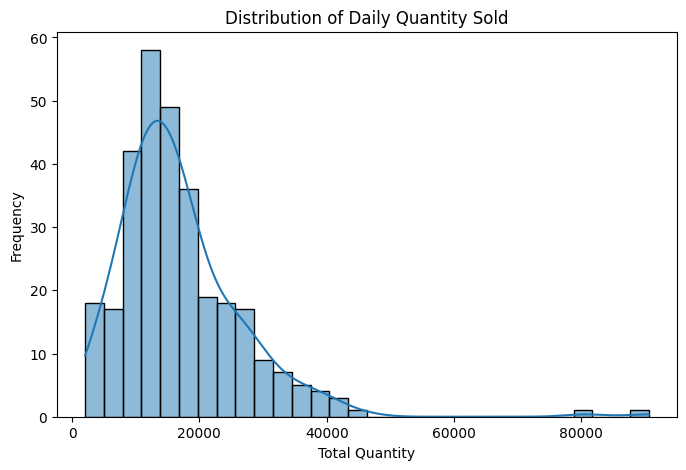

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(daily_df['TotalQuantity'], kde=True)
plt.title("Distribution of Daily Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Frequency")
plt.show()

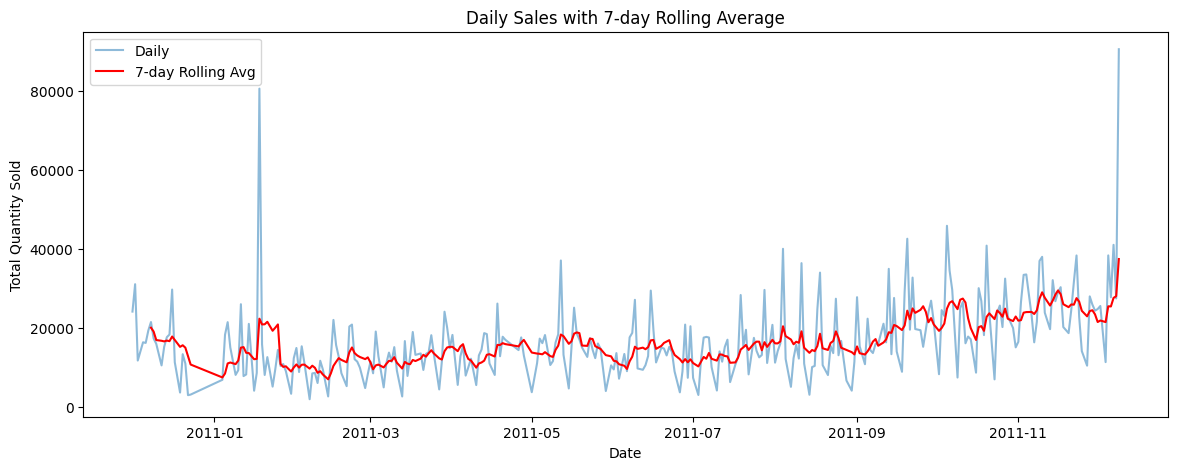

In [24]:
# 7 day rolling average

daily_df['Rolling7'] = daily_df['TotalQuantity'].rolling(7).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_df['Date'], daily_df['TotalQuantity'], alpha=0.5, label="Daily")
plt.plot(daily_df['Date'], daily_df['Rolling7'], color='red', label="7-day Rolling Avg")
plt.title("Daily Sales with 7-day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.legend()
plt.show()

Results

The blue line indicates the normal daily sales including the spiked days
The red line is the underlying trend whhich is smoothened

Multivariate analysis

In [25]:
transactions_per_day = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique().reset_index()
transactions_per_day.columns = ['Date', 'NumTransactions']

daily_df['Date'] = pd.to_datetime(daily_df['Date'])
transactions_per_day['Date'] = pd.to_datetime(transactions_per_day['Date'])

In [26]:
merged = pd.merge(daily_df, transactions_per_day, on='Date')

Relationship between sales and number of transactions

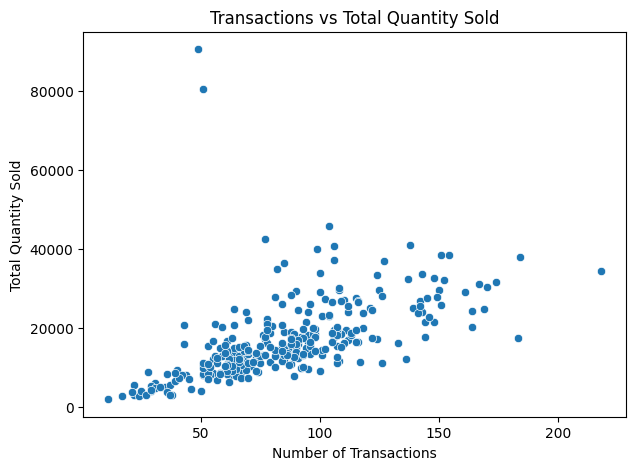

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=merged, x="NumTransactions", y="TotalQuantity")
plt.title("Transactions vs Total Quantity Sold")
plt.xlabel("Number of Transactions")
plt.ylabel("Total Quantity Sold")
plt.show()


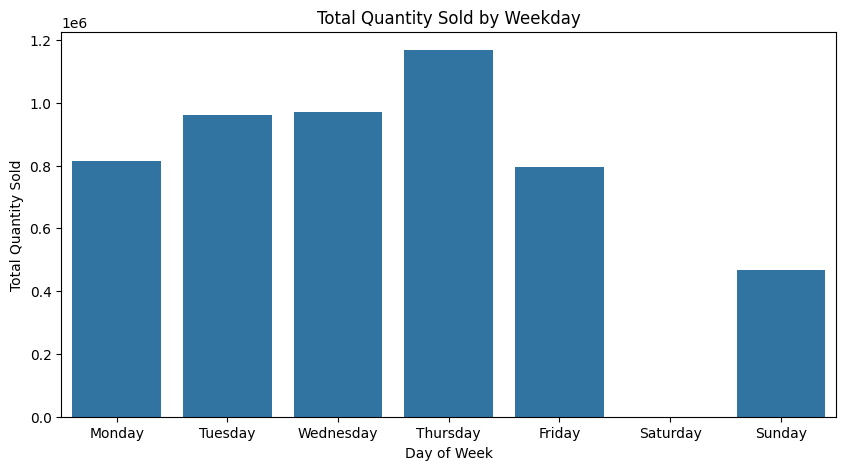

In [28]:
# Weekly seasonality

df['Weekday'] = df['InvoiceDate'].dt.day_name()

weekday_demand = df.groupby('Weekday')['Quantity'].sum().reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_demand.index, y=weekday_demand.values)
plt.title("Total Quantity Sold by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Total Quantity Sold")
plt.show()

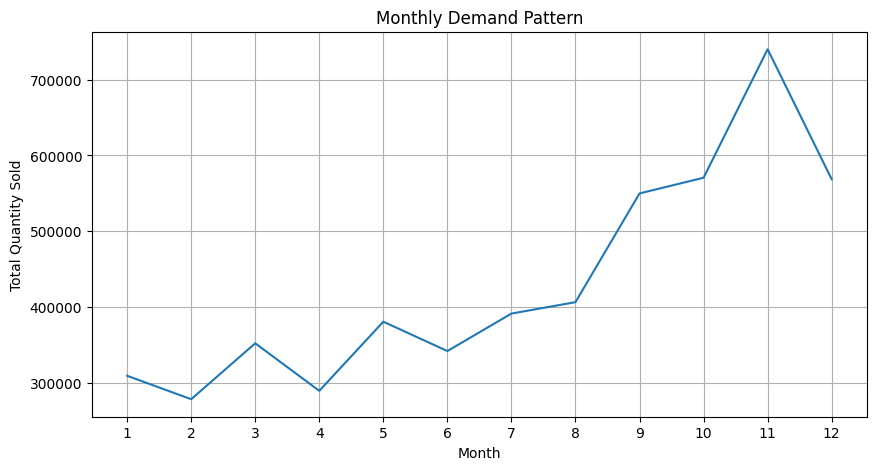

In [29]:
# monthly seasonality

df['Month'] = df['InvoiceDate'].dt.month

monthly_demand = df.groupby('Month')['Quantity'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_demand.index, y=monthly_demand.values)
plt.title("Monthly Demand Pattern")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

Machine learning prep

In [30]:
import numpy as np

df_ml = daily_df.copy()
df_ml['Date'] = pd.to_datetime(df_ml['Date'])
df_ml = df_ml.set_index('Date')

In [31]:
# lagging features

df_ml['lag_1'] = df_ml['TotalQuantity'].shift(1)
df_ml['lag_7'] = df_ml['TotalQuantity'].shift(7)
df_ml['lag_30'] = df_ml['TotalQuantity'].shift(30)

In [32]:
df_ml['roll_7'] = df_ml['TotalQuantity'].rolling(window=7).mean()
df_ml['roll_30'] = df_ml['TotalQuantity'].rolling(window=30).mean()

In [33]:
df_ml['dayofweek'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month
df_ml['is_weekend'] = df_ml['dayofweek'].isin([5,6]).astype(int)

In [34]:
df_ml = df_ml.dropna()

In [35]:
df_ml.head()

,TotalQuantity,Rolling7,lag_1,lag_7,lag_30,roll_7,roll_30,dayofweek,month,is_weekend
Date,,,,,,,,,,
2011-01-16,4204,12170.714286,21108.0,15122.0,24215.0,12170.714286,14507.833333,6,1,1
2011-01-17,8714,12243.857143,4204.0,8202.0,31142.0,12243.857143,13760.233333,0,1,0
2011-01-18,80618,22419.714286,8714.0,9387.0,11839.0,22419.714286,16052.866667,1,1,0
2011-01-19,15902,20965.285714,80618.0,26083.0,16449.0,20965.285714,16034.633333,2,1,0
2011-01-20,8185,21006.142857,15902.0,7899.0,16291.0,21006.142857,15764.433333,3,1,0


In [36]:
y = df_ml ['TotalQuantity']
X = df_ml.drop(columns=['TotalQuantity'])

In [37]:
test_days = 90
X_train = X.iloc[:-test_days]
y_train = y.iloc[:-test_days]
X_test = X.iloc[-test_days:]
y_test = y.iloc[-test_days:]

Random Forest for demand forecasting

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
#  Initialize RandomForest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [40]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [41]:
y_pred_rf = rf.predict(X_test)


In [42]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae, rmse, r2 = evaluate(y_test, y_pred_rf)

In [64]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [43]:
print("RandomForest Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

RandomForest Performance:
MAE  : 22013.53
RMSE : 26428.94
R^2  : -4.3943


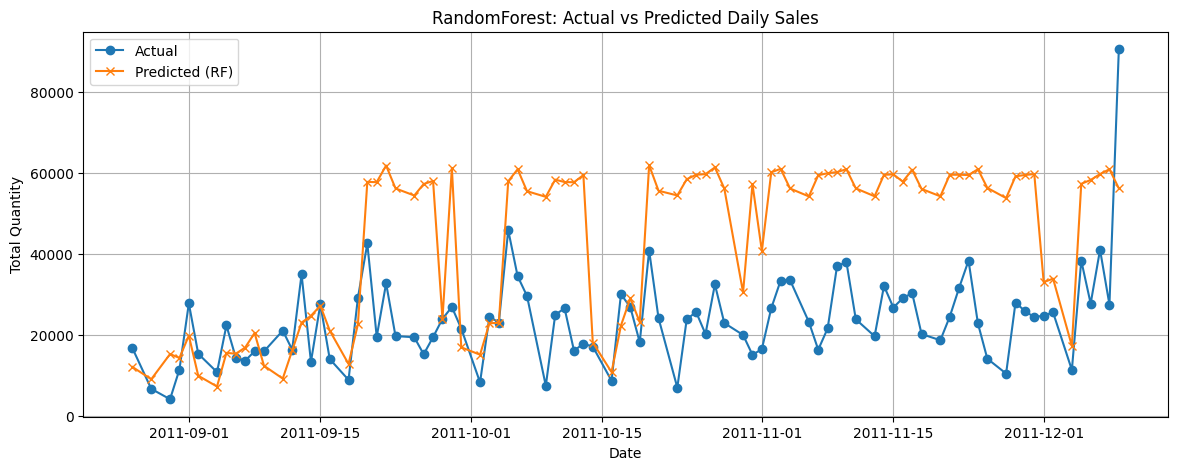

In [44]:

#  Plot actual vs predicted
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred_rf, label="Predicted (RF)", marker='x')
plt.title("RandomForest: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.legend()
plt.grid(True)
plt.show()

Neural network for demand forecasting

In [45]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [48]:
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [49]:
y_pred_mlp = mlp.predict(X_test_scaled)

In [50]:
mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

In [65]:
with open("mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)

In [51]:
print("MLP Regressor Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

MLP Regressor Performance:
MAE  : 12671.93
RMSE : 15645.81
R^2  : -0.8905


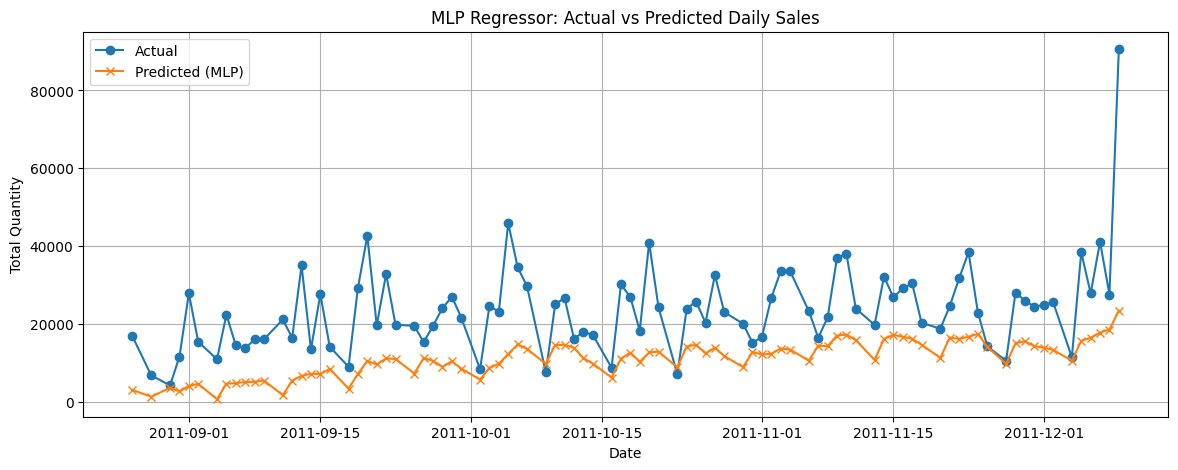

In [52]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual", marker='o')
plt.plot(y_test.index, y_pred_mlp, label="Predicted (MLP)", marker='x')
plt.title("MLP Regressor: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.legend()
plt.grid(True)
plt.show()

LSTM for daily demand forecast

In [53]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [54]:
df_lstm = daily_df.copy()

df_lstm['Date'] = pd.to_datetime(df_lstm['Date'])
df_lstm = df_lstm.sort_values('Date')

scaler = MinMaxScaler()
df_lstm['TotalQuantity_scaled'] = scaler.fit_transform(
    df_lstm['TotalQuantity'].values.reshape(-1,1)
)

In [67]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [55]:
def create_sequences(data, seq_length):
    X = []
    y = []

    data = data.reshape(-1, 1)
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X, y = create_sequences(df_lstm['TotalQuantity_scaled'].values, SEQ_LENGTH)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (275, 30, 1)
y shape: (275, 1)


In [56]:
from sklearn.model_selection import train_test_split


TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (220, 30, 1)
X_test: (55, 30, 1)


In [57]:
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0192 - val_loss: 0.0174
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0069 - val_loss: 0.0188
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0072 - val_loss: 0.0181
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0074 - val_loss: 0.0207
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0086 - val_loss: 0.0190
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0095 - val_loss: 0.0192
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0067 - val_loss: 0.0201
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0055 - val_loss: 0.0190
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0061 - val_loss: 0.0200
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0077 - val_loss: 0.0182
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0109 - val_loss: 0.0218
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0063 - val_l

In [66]:
model.save("lstm_model.h5")

In [58]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1,1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [59]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("LSTM Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

LSTM Performance:
MAE  : 11453.39
RMSE : 15756.29
R^2  : -0.7222


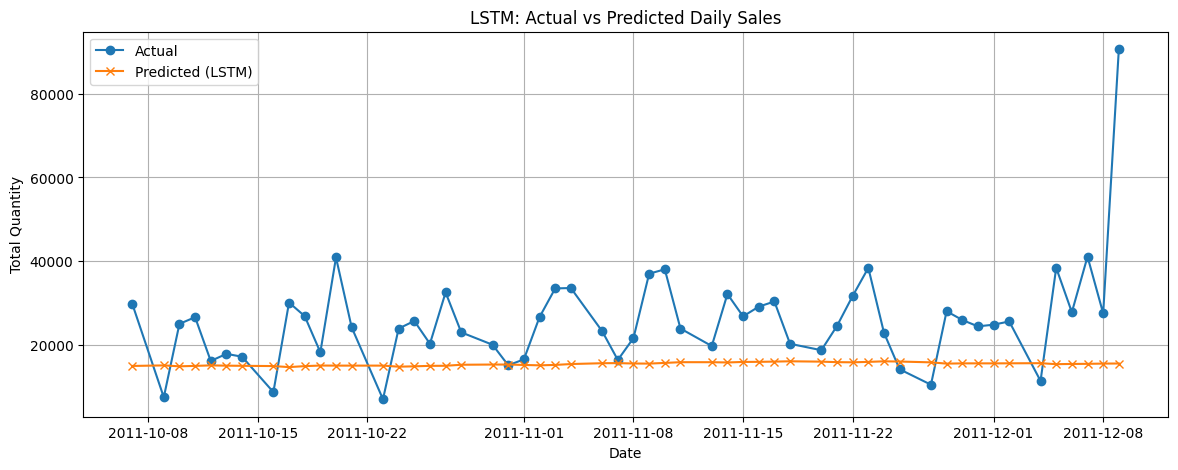

In [60]:
plt.figure(figsize=(14,5))
plt.plot(df_lstm['Date'][-len(y_true):], y_true, label="Actual", marker='o')
plt.plot(df_lstm['Date'][-len(y_pred):], y_pred, label="Predicted (LSTM)", marker='x')
plt.title("LSTM: Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
!pip install streamlit
!pip install pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.9 MB/s eta 0:00:00


In [68]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [75]:
!git remote add origin https://github.com/monixquello/datascience.git

error: remote origin already exists.


In [70]:
!git add app.py lstm_model.h5 rf_model.pkl scaler.pkl requirements.txt

In [71]:
!git commit -m "Add all project files"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a7ce12072007.(none)')


In [73]:
!git config --global user.email "monicahmirembe540@gmailcom"
!git config --global user.name "monixquello"

In [76]:
!git push -u origin refactored

error: src refspec refactored does not match any
error: failed to push some refs to 'https://github.com/monixquello/datascience/blob/refactored'


In [77]:
!git remote add origin https://github.com/monixquello/datascience.git

error: remote origin already exists.


In [78]:
!git checkout -b refactored

Switched to a new branch 'refactored'


In [79]:
!git add .

error: open("drive/MyDrive/90-1 by kizz.gdoc"): Operation not supported
error: unable to index file 'drive/MyDrive/90-1 by kizz.gdoc'
fatal: adding files failed


In [80]:
!echo "*.gdoc" >> .gitignore

In [81]:
!git add .

error: open("drive/MyDrive/Contact Information.gform"): Operation not supported
error: unable to index file 'drive/MyDrive/Contact Information.gform'
fatal: adding files failed


In [82]:
!echo "*.gdoc" >> .gitignore

In [84]:
!git add app.py lstm_model.h5 rf_model.pkl scaler.pkl requirements.txt


In [85]:
!git commit -m "Add project files"
!git push -u origin refactored


[refactored (root-commit) aeb812b] Add project files
 5 files changed, 97 insertions(+)
 create mode 100644 app.py
 create mode 100644 lstm_model.h5
 create mode 100644 requirements.txt
 create mode 100644 rf_model.pkl
 create mode 100644 scaler.pkl
fatal: repository 'https://github.com/monixquello/datascience/blob/refactored/' not found


In [86]:
!git remote add origin https://github.com/monixquello/datascience.git

error: remote origin already exists.


In [87]:
!git remote remove origin

In [88]:
!git remote add origin https://github.com/monixquello/datascience.git

In [89]:
!git branch -M refactored

In [90]:
!git push -u origin refactored

fatal: could not read Username for 'https://github.com': No such device or address


In [92]:
!git fetch origin refactored

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 556.61 KiB | 1.95 MiB/s, done.
From https://github.com/monixquello/datascience
 * branch            refactored -> FETCH_HEAD
 * [new branch]      refactored -> origin/refactored


In [93]:
!git merge origin/refactored

fatal: refusing to merge unrelated histories


In [94]:
!git pull origin refactored --allow-unrelated-histories

From https://github.com/monixquello/datascience
 * branch            refactored -> FETCH_HEAD
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command line to override the configured default per
hint: invocation.
fatal: Need to specify how to reconcile divergent branches.


In [95]:
!git push -u origin refactored

fatal: could not read Username for 'https://github.com': No such device or address


In [97]:
!git push -u origin refactored --force


fatal: could not read Username for 'https://github.com': No such device or address


Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 811.21 KiB | 1.44 MiB/s, done.
Total 7 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/monixquello/datascience.git
 + 4b4c590...aeb812b refactored -> refactored (forced update)


In [99]:
!git add grp16.ipynb
!git commit -m "Update notebook"
!git push -u origin refactored


fatal: pathspec 'grp16.ipynb' did not match any files
On branch refactored
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	drive/
	mlp_model.pkl
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
fatal: could not read Username for 'https://github.com': No such device or address


In [100]:
print(os.getcwd())

/content


In [101]:
print(os.listdir())

['.config', 'app.py', 'lstm_model.h5', '.ipynb_checkpoints', '.git', 'requirements.txt', 'mlp_model.pkl', 'rf_model.pkl', '.gitignore', 'scaler.pkl', 'drive', 'sample_data']


In [102]:
!ls /content/drive/MyDrive/

'03 CSS Fundamentals'
 2023-07-11.mp4
 57C1D0AB-C56B-497D-8668-7FEC246A6A23.mp4
'90-1 by kizz.gdoc'
'Acceptance Form (1).docx'
'Acceptance Form.docx'
'Agent onboarding App.mp4'
 Assets
'Bootcamp acceptance.docx'
 caldav-monicah.mirembe@entapps.com.mobileconfig
'catalyst project'
 Classroom
'Colab Notebooks'
'Contact Information.gform'
'CONTRACT OF EMPLOYMENT MIREMBE MONICA (1).docx.pdf'
'CONTRACT OF EMPLOYMENT MIREMBE MONICA.docx'
'CONTRACT OF EMPLOYMENT MIREMBE MONICA.docx.pdf'
'Copy of AICE AI Prompt Sheet.gsheet'
'Copy of AICE AI ToolKit.gsheet'
'Copy of AICE** Milestone #1 Worksheet (1).gdoc'
'Copy of AICE** Milestone #1 Worksheet.gdoc'
'Copy of AICE Skills Tracker .gsheet'
'Copy of AiCE Target Industry Workbook (1).gsheet'
'Copy of AiCE Target Industry Workbook.gsheet'
'Copy of ALX AICE**: Milestone #1 Rubric.gdoc'
'Copy of ALX AICE: Milestone #2 Rubric.gdoc'
'Copy of ALX AICE: Milestone #2 Worksheet.gdoc'
'Copy of ALX AICE: Milestone #3 Rubric.gdoc'
'Copy of ALX AICE: Milestone #

In [103]:
!find /content -name ".git"


/content/.git


In [104]:
!cp "/content/drive/MyDrive/Colab Notebooks/grp16.ipynb" /content/


In [105]:
%cd /content
!ls


/content
app.py	grp16.ipynb    mlp_model.pkl	 rf_model.pkl  scaler.pkl
drive	lstm_model.h5  requirements.txt  sample_data


In [106]:
!git add grp16.ipynb app.py lstm_model.h5 rf_model.pkl mlp_model.pkl scaler.pkl requirements.txt
!git commit -m "Add notebook and project files"


[refactored 36869cb] Add notebook and project files
 2 files changed, 1 insertion(+)
 create mode 100644 grp16.ipynb
 create mode 100644 mlp_model.pkl
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 621.53 KiB | 3.55 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/refactored.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-

In [107]:
%cd /content
!git reset HEAD~1


/content


In [108]:
!git add grp16.ipynb app.py lstm_model.h5 rf_model.pkl mlp_model.pkl scaler.pkl requirements.txt
!git commit -m "Add notebook and project files"


[refactored 1dde331] Add notebook and project files
 2 files changed, 1 insertion(+)
 create mode 100644 grp16.ipynb
 create mode 100644 mlp_model.pkl


In [110]:
!git log --oneline


1dde331 (HEAD -> refactored) Add notebook and project files
aeb812b Add project files


In [111]:
%cd /content
!git reset --soft HEAD~1


/content


In [112]:
!git add grp16.ipynb app.py lstm_model.h5 rf_model.pkl mlp_model.pkl scaler.pkl requirements.txt
!git commit -m "Add notebook and project files"


[refactored 7ab11cf] Add notebook and project files
 2 files changed, 1 insertion(+)
 create mode 100644 grp16.ipynb
 create mode 100644 mlp_model.pkl
